# Sentiment Analysis Classification Metrics for Italian Models

This notebook exposes the results of the sentiment analysis classification models trained and evaluated on the FEEL-IT dataset.
We compare two models:
- **ITA_BERT** (Italian BERT)
- **UmBERTo**

## 1. Metrics Comparison
The test metrics (Accuracy, Precision, Recall, F1 Score) for both models are presented below.

In [1]:
import pandas as pd
import os

ita_bert_metrics_path = '1_ITA_BERT_SA_FEEL-IT/output_ita_bert/test_metrics.csv'
umberto_metrics_path = '2_UmBERTo_SA_FEEL-IT/output_umberto/test_metrics.csv'

df_ita_bert = pd.read_csv(ita_bert_metrics_path)
df_umberto = pd.read_csv(umberto_metrics_path)

df_ita_bert['Model'] = 'ITA_BERT'
df_umberto['Model'] = 'UmBERTo'

df_combined = pd.concat([df_ita_bert, df_umberto]).set_index('Model')
df_combined

,Accuracy,Precision,Recall,F1_Score
Model,,,,
ITA_BERT,0.852941,0.842105,0.727273,0.780488
UmBERTo,0.911765,0.936842,0.809091,0.868293


## 2. First Sample Analysis - Interpretability
Here we expose the first sample from the test set, analyzing its predictions using **LIME** and **SHAP** explainers for both models.

### ITA_BERT: First Sample Explanations
**LIME Explanation:**
![ITA_BERT LIME](1_ITA_BERT_SA_FEEL-IT/output_ita_bert/lime_explanation_0.png)

**SHAP Explanation:**
![ITA_BERT SHAP](1_ITA_BERT_SA_FEEL-IT/output_ita_bert/shap_explanation_0.png)

### UmBERTo: First Sample Explanations
**LIME Explanation:**
![UmBERTo LIME](2_UmBERTo_SA_FEEL-IT/output_umberto/lime_explanation_0.png)

**SHAP Explanation:**
![UmBERTo SHAP](2_UmBERTo_SA_FEEL-IT/output_umberto/shap_explanation_0.png)

### Description and Interpretation

**Metrics Interpretation:**
- **UmBERTo** outperforms **ITA_BERT** across all metrics on the evaluated dataset. UmBERTo achieves an accuracy of ~91.2% and an F1 score of ~86.8%, compared to ITA_BERT's accuracy of ~85.3% and F1 score of ~78.0%. 
- UmBERTo demonstrates higher precision (~93.7% vs ~84.2%) and recall (~80.9% vs ~72.7%), making it the superior model for sentiment classification on this Italian text dataset.

**Sample Interpretability (LIME & SHAP):**
- The images above visualize the word contributions (positive or negative impact on the sentiment prediction) for the first sample.
- **LIME** highlights specific words and their weights contributing to the predicted class locally.
- **SHAP** provides a more global perspective on feature importance, showing the base value and how each token pushes the model output from the base value to the final prediction.
- Analyzing both allows us to verify if the models are focusing on semantically meaningful words (like positive/negative adjectives) rather than learning spurious correlations (like punctuation or stop words).

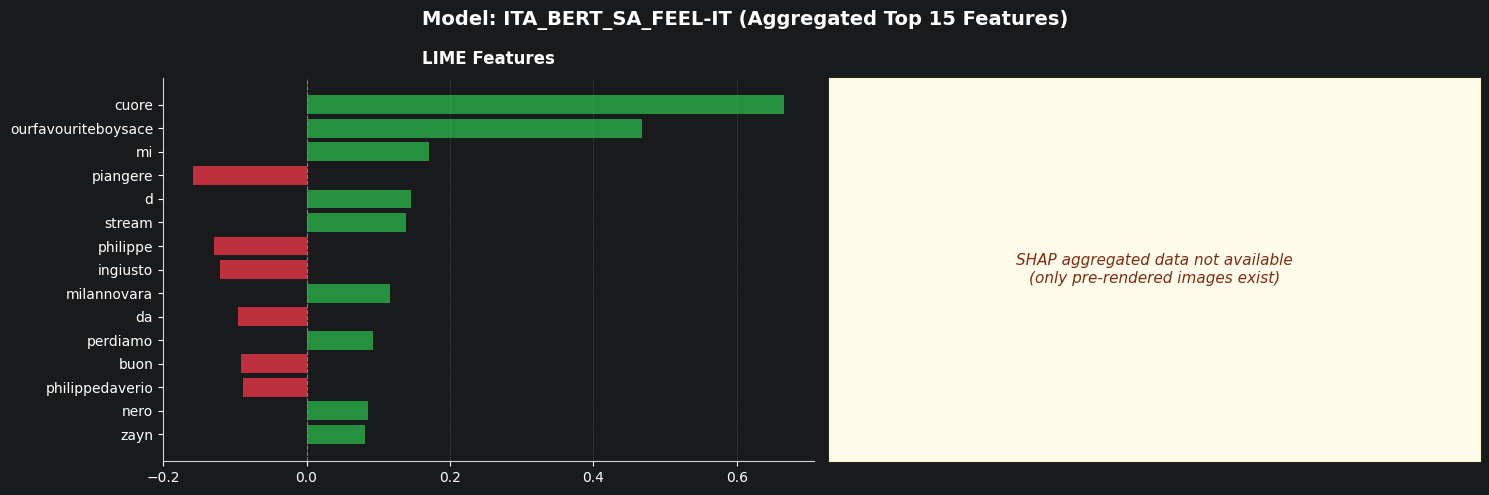

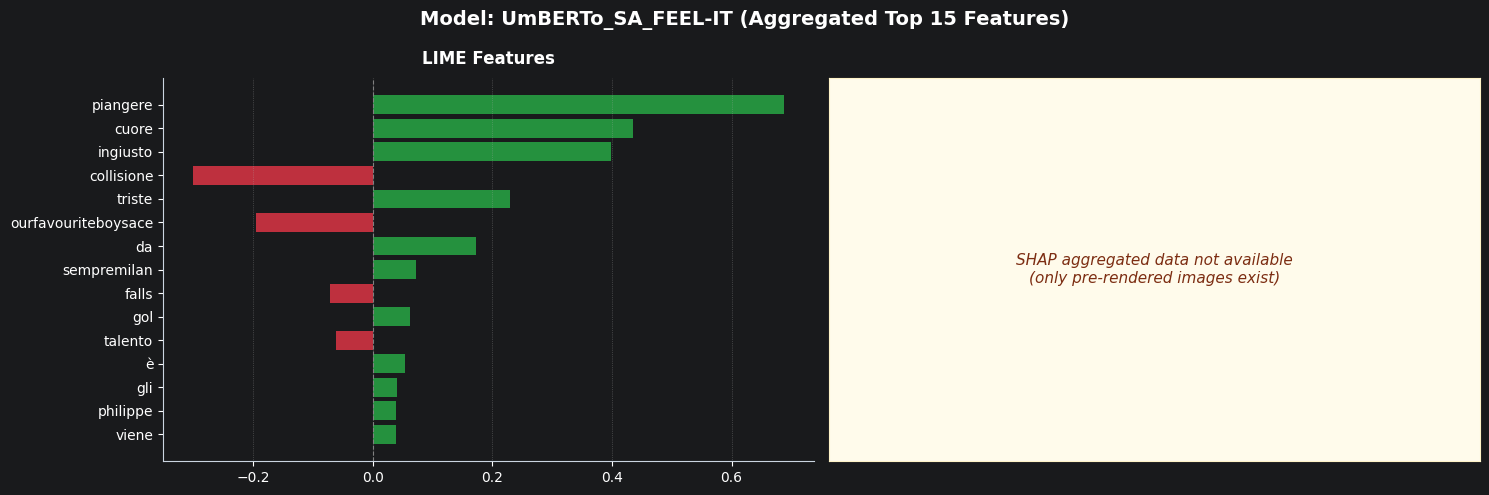

In [2]:
import os
import re
import json
from pathlib import Path
from collections import defaultdict
import matplotlib.pyplot as plt
import numpy as np

def aggregate_model_explanations(model_dir):
    lime_w = defaultdict(float)
    shap_w = defaultdict(float)
    
    model_path = Path(model_dir)
    if not model_path.exists():
        return [], []
        
    for root, dirs, files in os.walk(model_path):
        for f in files:
            path = Path(root) / f
            if f == 'lime_summary.json':
                try:
                    with open(path, 'r', encoding='utf-8') as file:
                        data = json.load(file)
                    for entry in data:
                        for w, wt in entry.get('top_words', []):
                            cw = w.strip().strip(',.-!?;:\\"\'()[]{}').lower()
                            if cw: lime_w[cw] += wt
                except Exception:
                    pass
            elif f.startswith('lime_explanation_') and f.endswith('.html'):
                try:
                    with open(path, 'r', encoding='utf-8') as file:
                        content = file.read()
                    m = re.search(r'exp\.show\(\s*(\[.*?\])\s*,\s*\d+,\s*exp_div\);', content)
                    if m:
                        data = json.loads(m.group(1))
                        for w, wt in data:
                            cw = w.strip().strip(',.-!?;:\\"\'()[]{}').lower()
                            if cw: lime_w[cw] += wt
                except Exception:
                    pass
            elif f == 'shap_summary.json':
                try:
                    with open(path, 'r', encoding='utf-8') as file:
                        data = json.load(file)
                    for entry in data:
                        for t, wt in entry.get('top_tokens', []):
                            ct = t.strip().strip(',.-!?;:\\"\'()[]{}').lower()
                            if ct: shap_w[ct] += wt
                except Exception:
                    pass
                        
    top_lime = sorted(lime_w.items(), key=lambda x: abs(x[1]), reverse=True)[:15]
    top_shap = sorted(shap_w.items(), key=lambda x: abs(x[1]), reverse=True)[:15]
    return top_lime, top_shap

italian_models = {
    'ITA_BERT_SA_FEEL-IT': '1_ITA_BERT_SA_FEEL-IT',
    'UmBERTo_SA_FEEL-IT': '2_UmBERTo_SA_FEEL-IT'
}

for model_name, model_dir in italian_models.items():
    top_lime, top_shap = aggregate_model_explanations(model_dir)
    
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))
    fig.suptitle(f"Model: {model_name} (Aggregated Top 15 Features)", fontsize=14, fontweight='bold')
    
    if top_lime:
        lime_words, lime_weights = zip(*top_lime[::-1])
        colors = ['#28a745' if w > 0 else '#dc3545' for w in lime_weights]
        ax1.barh(lime_words, lime_weights, color=colors, alpha=0.85)
        ax1.set_title("LIME Features", fontsize=12, fontweight='bold', pad=10)
        ax1.axvline(0, color='gray', linestyle='--', linewidth=0.8)
        ax1.spines['top'].set_visible(False)
        ax1.spines['right'].set_visible(False)
        ax1.spines['left'].set_color('#cbd5e1')
        ax1.spines['bottom'].set_color('#cbd5e1')
        ax1.grid(axis='x', linestyle=':', alpha=0.5)
    else:
        ax1.text(0.5, 0.5, "No LIME data found", ha='center', va='center', fontsize=12, color='gray')
        ax1.axis('off')
        
    if top_shap:
        shap_tokens, shap_weights = zip(*top_shap[::-1])
        colors = ['#007bff' if w > 0 else '#ffc107' for w in shap_weights]
        ax2.barh(shap_tokens, shap_weights, color=colors, alpha=0.85)
        ax2.set_title("SHAP Features", fontsize=12, fontweight='bold', pad=10)
        ax2.axvline(0, color='gray', linestyle='--', linewidth=0.8)
        ax2.spines['top'].set_visible(False)
        ax2.spines['right'].set_visible(False)
        ax2.spines['left'].set_color('#cbd5e1')
        ax2.spines['bottom'].set_color('#cbd5e1')
        ax2.grid(axis='x', linestyle=':', alpha=0.5)
    else:
        ax2.text(0.5, 0.5, "SHAP aggregated data not available\n(only pre-rendered images exist)", 
                 ha='center', va='center', fontsize=11, color='#7c2d12', style='italic')
        ax2.set_facecolor('#fffbeb')
        ax2.spines['top'].set_color('#fef3c7')
        ax2.spines['right'].set_color('#fef3c7')
        ax2.spines['left'].set_color('#fef3c7')
        ax2.spines['bottom'].set_color('#fef3c7')
        ax2.set_xticks([])
        ax2.set_yticks([])
        
    plt.tight_layout()
    plt.show()
